![alt text](image.png)

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)

In [3]:
path = "../../data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


In [4]:
df1 = dfs[list(dfs.keys())[0]] 

se nota con el numero de unicos que el primary key para voltear es SamplingOperations_code  

In [5]:
df1.nunique()

TaxonName                            2292
TaxonCode                            2292
SamplingOperations_code             49231
CodeSite_SamplingOperations          8404
Date_SamplingOperation               2237
Abundance_nbcell                      408
TotalAbundance_SamplingOperation      188
Abundance_pm                        16667
dtype: int64

a ver mi teoria loca es que el ibd es calculado solo con taxones así:

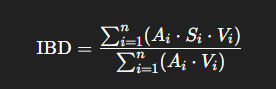

y que gracias a el super completo y coomprensivo eda de Heri se puede pensar así 

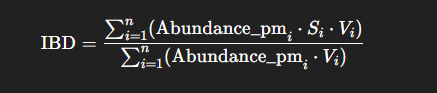


y que la regresión nos dará los valores de los demas 

In [43]:
# 1) columnas que QUIERES mantener en la llave (todas menos: TaxonName y Abundance_nbcell;
#    y quitamos TaxonCode/Abundance_pm porque se usan para columnas/valores)
cols_key = [c for c in df1.columns 
            if c not in ['TaxonName', 'Abundance_nbcell', 'TaxonCode', 'Abundance_pm']]

# 2) tabla pivote:
#    - index = todas las columnas que quieres conservar (parte del key)
#    - columns = códigos de taxón
#    - values = Abundance_pm
#    - aggfunc='sum' por si hay duplicados del mismo taxón en la misma muestra
wide = (
    df1.pivot_table(index=cols_key,
                   columns='TaxonCode',
                   values='Abundance_pm',
                   aggfunc='sum')
      .reset_index()
)

# opcional: quitar el nombre del eje de columnas
wide.columns.name = None
len(wide)


49231

In [44]:
sites = dfs[list(dfs.keys())[1]]
len(sites)

8404

In [45]:
taxones = pd.merge(wide, sites, on='CodeSite_SamplingOperations',how = 'left')
len(taxones)

49231

In [46]:
pressure = dfs[list(dfs.keys())[4]]
len(pressure)

49231

In [47]:
taxones_pressure = pd.merge(taxones, pressure, on=['SamplingOperations_code', 'CodeSite_SamplingOperations','Date_SamplingOperation'],how = 'inner')
len(taxones_pressure)

49231

Ahora con el de train y crear el df a parte de los que serán la prediccion 

In [48]:
train =  dfs[list(dfs.keys())[3]]
len(train)

43783

In [49]:
taxones_pressure_train = pd.merge(taxones_pressure,train, on = 'SamplingOperations_code', how= 'inner')
len(taxones_pressure_train)


43783

In [53]:
# 1) Merge de entrenamiento (con respuestas)
taxones_pressure_train = pd.merge(
    taxones_pressure,
    train,
    on='SamplingOperations_code',
    how='inner'
)

# 2) Predicción = anti-join por clave (códigos que NO aparecen en train)
keys_train = set(train['SamplingOperations_code'].dropna().unique())
taxones_pressure_predict = taxones_pressure[
    ~taxones_pressure['SamplingOperations_code'].isin(keys_train)
].copy()

# 3) Diagnósticos de unicidad (si hay duplicados, el inner puede "multiplicar" filas)
dup_tp  = taxones_pressure['SamplingOperations_code'].duplicated(keep=False).sum()
dup_tr  = train['SamplingOperations_code'].duplicated(keep=False).sum()
print(f"Duplicados por clave en taxones_pressure: {dup_tp}")
print(f"Duplicados por clave en train:            {dup_tr}")

# 4) Checks rápidos de conteo
n_total   = len(taxones_pressure)
n_train   = len(taxones_pressure_train)
n_predict = len(taxones_pressure_predict)
print(f"len(taxones_pressure)        = {n_total}")
print(f"len(taxones_pressure_train)  = {n_train}")
print(f"len(taxones_pressure_predict)= {n_predict}")

# OJO: Esta igualdad SOLO se cumple si `train` tiene a lo sumo 1 fila por código
# y `taxones_pressure` también es único por código:
#     n_train + n_predict == n_total
# Si no, verás que n_train puede ser mayor que el número de códigos coincidentes
# por el "cartesian product" del inner join. Para verificar la igualdad por CÓDIGOS:
codes_total   = set(taxones_pressure['SamplingOperations_code'].dropna().unique())
codes_train_m = set(taxones_pressure_train['SamplingOperations_code'].dropna().unique())
codes_predict = set(taxones_pressure_predict['SamplingOperations_code'].dropna().unique())

print(f"# códigos en taxones_pressure        = {len(codes_total)}")
print(f"# códigos en taxones_pressure_train  = {len(codes_train_m)}")
print(f"# códigos en taxones_pressure_predict= {len(codes_predict)}")
print("¿Partición exacta por códigos?",
      len(codes_train_m | codes_predict) == len(codes_total)
      and len(codes_train_m & codes_predict) == 0)

# 5) Verificación explícita de no solapamiento de códigos entre train y predict
inter = codes_train_m & codes_predict
print(f"Códigos compartidos entre TRAIN y PREDICT (debería ser 0): {len(inter)}")

# 6) (Opcional) Si quieres forzar unicidad por código antes del merge:
#    a) en train (por ejemplo quedarte con la última observación)
# train_unique = train.sort_values('SamplingOperations_code').drop_duplicates('SamplingOperations_code', keep='last')
# taxones_pressure_train = pd.merge(taxones_pressure, train_unique, on='SamplingOperations_code', how='inner')

#    b) en taxones_pressure (si corresponde)
# taxones_pressure_unique = taxones_pressure.sort_values('SamplingOperations_code').drop_duplicates('SamplingOperations_code', keep='last')

# 7) Guardar sin sobrescribir archivos
taxones_pressure_train.to_parquet("../../data/processed/taxones_pressure_train.parquet", index=False)
taxones_pressure_predict.to_parquet("../../data/processed/taxones_pressure_predict.parquet", index=False)


Duplicados por clave en taxones_pressure: 0
Duplicados por clave en train:            419
len(taxones_pressure)        = 49231
len(taxones_pressure_train)  = 43783
len(taxones_pressure_predict)= 5658
# códigos en taxones_pressure        = 49231
# códigos en taxones_pressure_train  = 43573
# códigos en taxones_pressure_predict= 5658
¿Partición exacta por códigos? True
Códigos compartidos entre TRAIN y PREDICT (debería ser 0): 0


In [54]:
train

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status
0,S04319000_20130724,5.2,0.256098,Bad
1,S06172100_20080716,6.1,0.298246,Bad
2,S03255920_20120802,3.7,0.157895,Bad
3,S04064720_20150710,4.9,0.228070,Bad
4,S05001500_20080726,5.3,0.251462,Bad
...,...,...,...,...
43778,S06165700_20230628,6.8,0.339181,Poor
43779,S06440770_20230524,15.3,0.836257,Good
43780,S06710030_20230627,18.4,1.000000,High
43781,S06036970_20230628,14.5,0.678571,Moderate


In [59]:
# Duplicados por clave
dup_keys = train[train.duplicated('SamplingOperations_code', keep=False)].copy()

# ¿Cuántos valores distintos de target por clave?
conflicts = (dup_keys
             .groupby('SamplingOperations_code')['IBD']
             .nunique(dropna=False)
             .reset_index(name='n_unique_target'))

# Claves con más de un valor de target distinto
bad_keys = conflicts[conflicts['n_unique_target'] > 1]['SamplingOperations_code']
print(f"Claves con conflictos de target: {len(bad_keys)}")

# (Opcional) mira algunos ejemplos
sample_conflicts = dup_keys[dup_keys['SamplingOperations_code'].isin(bad_keys)].sort_values('SamplingOperations_code').head(20)


Claves con conflictos de target: 5


In [62]:
key_col = 'SamplingOperations_code'

# 1) Quitar filas con bad_keys
train_no_bad = train[~train[key_col].isin(bad_keys)].copy()

# 2) Drop duplicates por clave (elige keep='last' o 'first')
train_cleaned_up = (
    train_no_bad
    .sort_values(key_col)
    .drop_duplicates(subset=key_col, keep='last')
    .reset_index(drop=True)
)

# Checks rápidos
print(f"Filas originales: {len(train)}")
print(f"Removidas por bad_keys: {len(train) - len(train_no_bad)}")
print(f"Removidas por duplicados: {len(train_no_bad) - len(train_cleaned_up)}")
print(f"Final (train_cleaned_up): {len(train_cleaned_up)}")

# Verificar unicidad por clave
assert not train_cleaned_up[key_col].duplicated().any(), "Quedaron duplicados por clave"


Filas originales: 43783
Removidas por bad_keys: 11
Removidas por duplicados: 204
Final (train_cleaned_up): 43568


In [64]:
taxones_pressure_train = pd.merge(taxones_pressure,train_cleaned_up, on = 'SamplingOperations_code', how= 'inner')
len(taxones_pressure_train)

43568

In [65]:
taxones_pressure_predict = taxones_pressure[
    ~taxones_pressure['SamplingOperations_code'].isin(train_cleaned_up['SamplingOperations_code'])
].copy()
len(taxones_pressure_predict)

5663

In [66]:
len(taxones_pressure_train)+len(taxones_pressure_predict)

49231

In [68]:
taxones_pressure_train.to_parquet("../../data/processed/taxones_pressure_train.parquet", index=False)
taxones_pressure_predict.to_parquet("../../data/processed/taxones_pressure_predict.parquet", index=False)

In [69]:
taxones_pressure_train

SamplingOperations_code CodeSite_SamplingOperations  \
0          S02000008_20170703                   S02000008   
1          S02000008_20200708                   S02000008   
2          S02000010_20070906                   S02000010   
3          S02000010_20090721                   S02000010   
4          S02000010_20110723                   S02000010   
...                       ...                         ...   
43563      S06999141_20160928                   S06999141   
43564      S06999179_20230628                   S06999179   
43565      S06999180_20160928                   S06999180   
43566      S06999189_20160928                   S06999189   
43567      S06999189_20220920                   S06999189   

      Date_SamplingOperation  TotalAbundance_SamplingOperation  Achaa01  \
0                 2017-07-03                               405      NaN   
1                 2020-07-08                               400      NaN   
2                 2007-09-06                               400      NaN   
3                 2009-07-21                               400      NaN   
4                 2011-07-23                               398      NaN   
...                      ...                               ...      ...   
43563             2016-09-28                               403      NaN   
43564             2023-06-28                               409      NaN   
43565             2016-09-28                               404      NaN   
43566             2016-09-28                               403      NaN   
43567             2022-09-20                               406      NaN   

       Achac01  Achaf01  Achaf02  Achal01  Acham01  Achan01  Achat01  \
0          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
1          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
2          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
3          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
4          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...   
43563      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43564      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43565      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43566      NaN      NaN  2.48139      NaN      NaN      NaN      NaN   
43567      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

        Achat02  Achat03  Achba01  Achbi01  Achbi02  Achbr01  Achca01  \
0           NaN      NaN      NaN      NaN      NaN      NaN      NaN   
1           NaN      NaN      NaN      NaN      NaN      NaN      NaN   
2           NaN      NaN      NaN      NaN      NaN      NaN      NaN   
3           NaN      NaN      NaN      NaN      NaN      NaN      NaN   
4           NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...         ...      ...      ...      ...      ...      ...      ...   
43563       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43564       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43565       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43566       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43567  4.926108      NaN      NaN      NaN      NaN      NaN      NaN   

       Achca02  Achca03  Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
0          NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
1          NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
2          NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
3          NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
4          NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...      ...   
43563      NaN      NaN      NaN      NaN      NaN      NaN    

La ultima de environmetal aprameter means en una cosa rara 

In [70]:
epm = dfs[list(dfs.keys())[5]]
len(epm)

3763903

In [71]:
# columnas clave
keys = ['CodeSite_SamplingOperations', 'SamplingOperations_code']

# hacemos el pivot: columnas = códigos de parámetro, valores = las tres medias
wide = (
    epm.pivot_table(
        index=keys,
        columns='Parametre_code',
        values=['Mean1Y', 'Mean180Days', 'Mean90Days'],
        aggfunc='first'              # o 'mean' si pudiera haber duplicados por llave+parámetro
    )
)

# aplanar MultiIndex de columnas -> Mean1Y_1319, Mean180Days_1319, Mean90Days_1319, ...
wide.columns = [f"{stat}_{code}" for stat, code in wide.columns]
wide = wide.reset_index()



In [72]:
wide.drop(columns= 'CodeSite_SamplingOperations')

,SamplingOperations_code,Mean180Days_1082,Mean180Days_1083,Mean180Days_1084,Mean180Days_1092,Mean180Days_1101,Mean180Days_1102,Mean180Days_1103,Mean180Days_1105,Mean180Days_1107,Mean180Days_1108,Mean180Days_1113,Mean180Days_1114,Mean180Days_1115,Mean180Days_1116,Mean180Days_1117,Mean180Days_1118,Mean180Days_1119,Mean180Days_1128,Mean180Days_1129,Mean180Days_1130,Mean180Days_1135,Mean180Days_1136,Mean180Days_1139,Mean180Days_1141,Mean180Days_1143,Mean180Days_1144,Mean180Days_1145,Mean180Days_1146,Mean180Days_1147,Mean180Days_1149,Mean180Days_1160,Mean180Days_1164,Mean180Days_1165,Mean180Days_1166,Mean180Days_1168,Mean180Days_1169,Mean180Days_1173,Mean180Days_1176,Mean180Days_1177,Mean180Days_1181,Mean180Days_1184,Mean180Days_1189,Mean180Days_1191,Mean180Days_1192,Mean180Days_1194,Mean180Days_1199,Mean180Days_1203,Mean180Days_1204,Mean180Days_1205,Mean180Days_1206,Mean180Days_1207,Mean180Days_1208,Mean180Days_1209,Mean180Days_1211,Mean180Days_1212,Mean180Days_1216,Mean180Days_1218,Mean180Days_1221,Mean180Days_1231,Mean180Days_1232,Mean180Days_1233,Mean180Days_1234,Mean180Days_1235,Mean180Days_1253,Mean180Days_1263,Mean180Days_1266,Mean180Days_1268,Mean180Days_1269,Mean180Days_1278,Mean180Days_1283,Mean180Days_1289,Mean180Days_1291,Mean180Days_1292,Mean180Days_1293,Mean180Days_1294,Mean180Days_1295,Mean180Days_1302,Mean180Days_1305,Mean180Days_1311,Mean180Days_1312,Mean180Days_1313,Mean180Days_1314,Mean180Days_1319,Mean180Days_1335,Mean180Days_1339,Mean180Days_1340,Mean180Days_1345,Mean180Days_1350,Mean180Days_1359,Mean180Days_1369,Mean180Days_1370,Mean180Days_1380,Mean180Days_1382,Mean180Days_1383,Mean180Days_1386,Mean180Days_1387,Mean180Days_1388,Mean180Days_1389,Mean180Days_1392,Mean180Days_1433,Mean180Days_1453,Mean180Days_1456,Mean180Days_1458,Mean180Days_1464,Mean180Days_1468,Mean180Days_1469,Mean180Days_1470,Mean180Days_1473,Mean180Days_1476,Mean180Days_1480,Mean180Days_1486,Mean180Days_1490,Mean180Days_1493,Mean180Days_1506,Mean180Days_1517,Mean180Days_1522,Mean180Days_1524,Mean180Days_1537,Mean180Days_1548,Mean180Days_1549,Mean180Days_1586,Mean180Days_1591,Mean180Days_1592,Mean180Days_1593,Mean180Days_1621,Mean180Days_1622,Mean180Days_1623,Mean180Days_1629,Mean180Days_1630,Mean180Days_1642,Mean180Days_1643,Mean180Days_1644,Mean180Days_1645,Mean180Days_1646,Mean180Days_1647,Mean180Days_1648,Mean180Days_1649,Mean180Days_1652,Mean180Days_1666,Mean180Days_1669,Mean180Days_1688,Mean180Days_1694,Mean180Days_1699,Mean180Days_1700,Mean180Days_1723,Mean180Days_1743,Mean180Days_1770,Mean180Days_1777,Mean180Days_1780,Mean180Days_1811,Mean180Days_1841,Mean180Days_1911,Mean180Days_1955,Mean180Days_1958,Mean180Days_1959,Mean180Days_1975,Mean180Days_2539,Mean180Days_2872,Mean180Days_2879,Mean180Days_2904,Mean180Days_2923,Mean180Days_2925,Mean180Days_3336,Mean180Days_5275,Mean180Days_5474,Mean180Days_5986,Mean180Days_6249,Mean180Days_6372,Mean180Days_6598,Mean180Days_6600,Mean180Days_7074,Mean180Days_XOMP,Mean1Y_1082,Mean1Y_1083,Mean1Y_1084,Mean1Y_1092,Mean1Y_1101,Mean1Y_1102,Mean1Y_1103,Mean1Y_1105,Mean1Y_1107,Mean1Y_1108,Mean1Y_1113,Mean1Y_1114,Mean1Y_1115,Mean1Y_1116,Mean1Y_1117,Mean1Y_1118,Mean1Y_1119,Mean1Y_1128,Mean1Y_1129,Mean1Y_1130,Mean1Y_1135,Mean1Y_1136,Mean1Y_1139,Mean1Y_1141,Mean1Y_1143,Mean1Y_1144,Mean1Y_1145,Mean1Y_1146,Mean1Y_1147,Mean1Y_1149,Mean1Y_1160,Mean1Y_1164,Mean1Y_1165,Mean1Y_1166,Mean1Y_1168,Mean1Y_1169,Mean1Y_1173,Mean1Y_1176,Mean1Y_1177,Mean1Y_1181,Mean1Y_1184,Mean1Y_1189,Mean1Y_1191,Mean1Y_1192,Mean1Y_1194,Mean1Y_1199,Mean1Y_1203,Mean1Y_1204,Mean1Y_1205,Mean1Y_1206,Mean1Y_1207,Mean1Y_1208,Mean1Y_1209,Mean1Y_1211,Mean1Y_1212,Mean1Y_1216,Mean1Y_1218,Mean1Y_1221,Mean1Y_1231,Mean1Y_1232,Mean1Y_1233,Mean1Y_1234,Mean1Y_1235,Mean1Y_1253,Mean1Y_1263,Mean1Y_1266,Mean1Y_1268,Mean1Y_1269,Mean1Y_1278,Mean1Y_1283,Mean1Y_1289,Mean1Y_1291,Mean1Y_1292,Mean1Y_1293,Mean1Y_1294,Mean1Y_1295,Mean1Y_1302,Mean1Y_1305,Mean1Y_1311,Mean1Y_1312,Mean1Y_1313,Mean1Y_1314,Mean1Y_1319,Mean1Y_1335,Mean1Y_1339,Mean1Y_1340,Mean1Y_1345,Mean1Y_

In [73]:
taxones_pressure_epm = pd.merge(taxones_pressure, wide, on= 'SamplingOperations_code',how = 'inner')

In [74]:
taxones_pressure_epm_train =pd.merge(taxones_pressure_epm,train_cleaned_up, on = 'SamplingOperations_code', how= 'inner')
len(taxones_pressure_train)

43568

In [75]:
taxones_pressure_epm_predict = taxones_pressure_epm[
    ~taxones_pressure_epm['SamplingOperations_code'].isin(train_cleaned_up['SamplingOperations_code'])
].copy()
len(taxones_pressure_epm_predict)

5663

In [76]:
len(taxones_pressure_epm_predict)+len(taxones_pressure_epm_train)

49231

In [77]:
taxones_pressure_epm_train.to_parquet("../../data/processed/taxones_pressure_epm_train.parquet", index=False)
taxones_pressure_epm_predict.to_parquet("../../data/processed/taxones_pressure_epm_predict.parquet", index=False)